# APEX Moto Sales Analysis — Exploratory Data Analysis (EDA)

This notebook explores the cleaned APEX Moto dataset produced by
`01_Data_Cleaning.ipynb` and answers the core business questions through
visualization: sales trend, product performance, customer demographics,
geography, and returns.

**Sections**
1. Setup & Load Cleaned Data
2. Sales Trend Analysis (yearly, monthly, cumulative, growth %, seasonality)
3. Product & Category Analysis (revenue, Pareto, ABC)
4. Customer Analysis (top customers, gender, income, age)
5. Geographic Analysis
6. Returns Analysis
7. Correlation & Distribution Analysis
8. Key Insights Summary


## 1. Setup & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

CLEAN_PATH = '../Dataset/Cleaned Data/'

master_df = pd.read_csv(CLEAN_PATH + 'master_sales_data.csv', parse_dates=['OrderDate', 'StockDate', 'BirthDate'])
customer_df = pd.read_csv(CLEAN_PATH + 'cleaned_customers.csv', parse_dates=['BirthDate'])
product_df = pd.read_csv(CLEAN_PATH + 'cleaned_products.csv')
returns_df = pd.read_csv(CLEAN_PATH + 'cleaned_returns.csv', parse_dates=['ReturnDate'])
territory_df = pd.read_csv(CLEAN_PATH + 'cleaned_territory.csv')

print('master_df:', master_df.shape)
master_df.head()


master_df: (56046, 51)


,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,Quantity,SourceYear,OrderYear,...,FullName,Age,AgeBand,IncomeBand,Region,Country,Continent,Revenue,COGS,Profit
0,2020-01-01,2019-09-21,SO45080,332,14657,1,1,1,2020,2020,...,John Thomas,63,55-64,Mid (40K-80K),Northwest,United States,North America,699.0982,413.1463,285.9519
1,2020-01-01,2019-12-05,SO45079,312,29255,4,1,1,2020,2020,...,Kyle Washington,67,65+,Mid (40K-80K),Southwest,United States,North America,3578.2700,2171.2942,1406.9758
2,2020-01-01,2019-10-29,SO45082,350,11455,9,1,1,2020,2020,...,Ross Sanz,48,45-54,High (80K-120K),Australia,Australia,Pacific,3374.9900,1898.0944,1476.8956
3,2020-01-01,2019-11-16,SO45081,338,26782,6,1,1,2020,2020,...,Seth Lewis,41,35-44,Low (<40K),Canada,Canada,North America,699.0982,413.1463,285.9519
4,2020-01-02,2019-12-15,SO45083,312,14947,10,1,1,2020,2020,...,Alejandro Chen,57,55-64,Low (<40K),United Kingdom,United Kingdom,Europe,3578.2700,2171.2942,1406.9758


In [2]:
def money_fmt(ax, axis='y'):
    fmt = mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
    if axis == 'y':
        ax.yaxis.set_major_formatter(fmt)
    else:
        ax.xaxis.set_major_formatter(fmt)


## 2. Sales Trend Analysis

### 2.1 Yearly Revenue & Profit

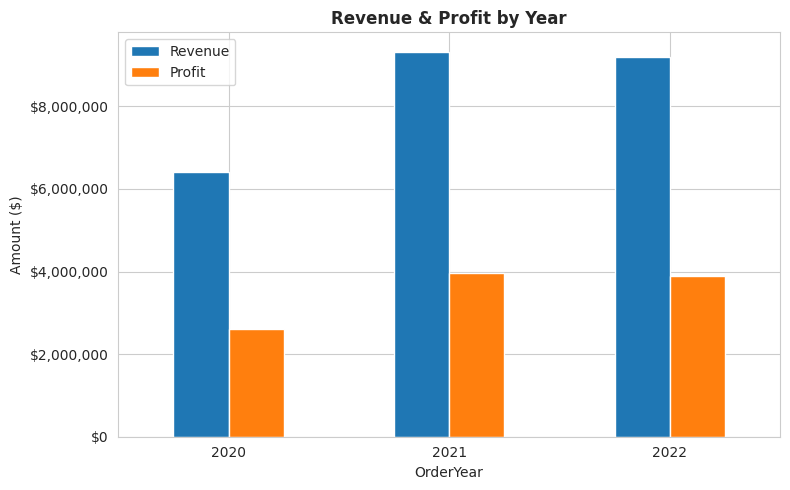

,Revenue,Profit
OrderYear,,
2020,6.404934e+06,2.601602e+06
2021,9.324204e+06,3.967084e+06
2022,9.185449e+06,3.889029e+06


In [3]:
yearly = master_df.groupby('OrderYear')[['Revenue', 'Profit']].sum()

ax = yearly.plot(kind='bar', figsize=(8, 5))
ax.set_title('Revenue & Profit by Year')
ax.set_ylabel('Amount ($)')
money_fmt(ax)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

yearly


### 2.2 Monthly Revenue Trend (Full Timeline)

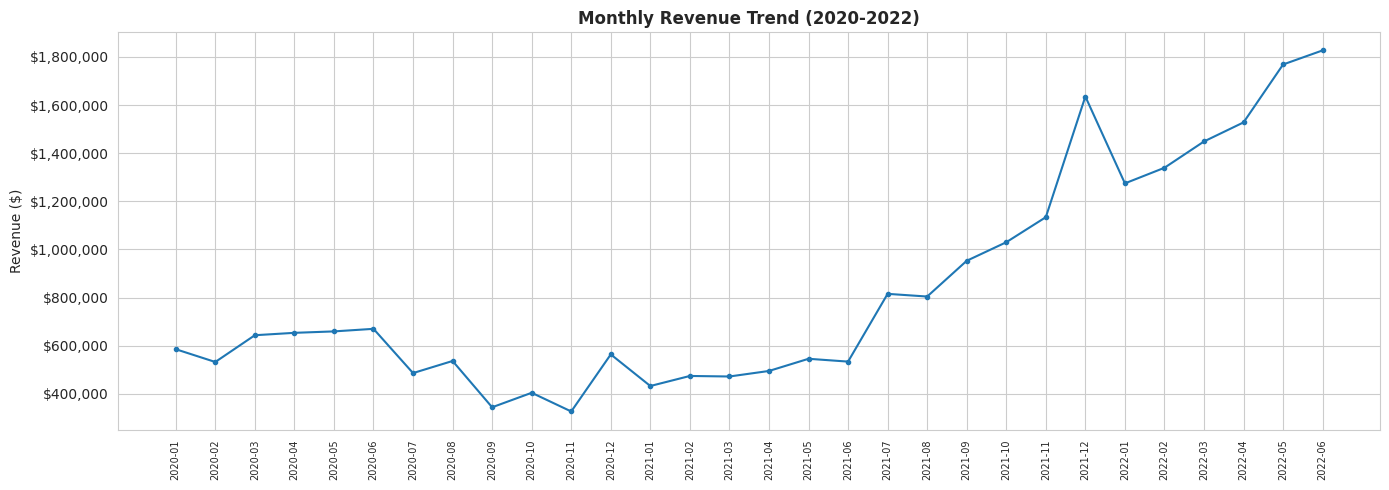

In [4]:
monthly = master_df.groupby('OrderYearMonth')['Revenue'].sum().reset_index()
monthly = monthly.sort_values('OrderYearMonth')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['OrderYearMonth'], monthly['Revenue'], marker='o', markersize=3, linewidth=1.5)
ax.set_title('Monthly Revenue Trend (2020-2022)')
ax.set_ylabel('Revenue ($)')
money_fmt(ax)
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()


### 2.3 Year-over-Year Growth %

In [5]:
yearly_growth = yearly.copy()
yearly_growth['Revenue_YoY_%'] = yearly_growth['Revenue'].pct_change() * 100
yearly_growth['Profit_YoY_%'] = yearly_growth['Profit'].pct_change() * 100
yearly_growth


,Revenue,Profit,Revenue_YoY_%,Profit_YoY_%
OrderYear,,,,
2020,6.404934e+06,2.601602e+06,NaN,NaN
2021,9.324204e+06,3.967084e+06,45.578462,52.486184
2022,9.185449e+06,3.889029e+06,-1.488109,-1.967570


### 2.4 Cumulative Revenue Over Time

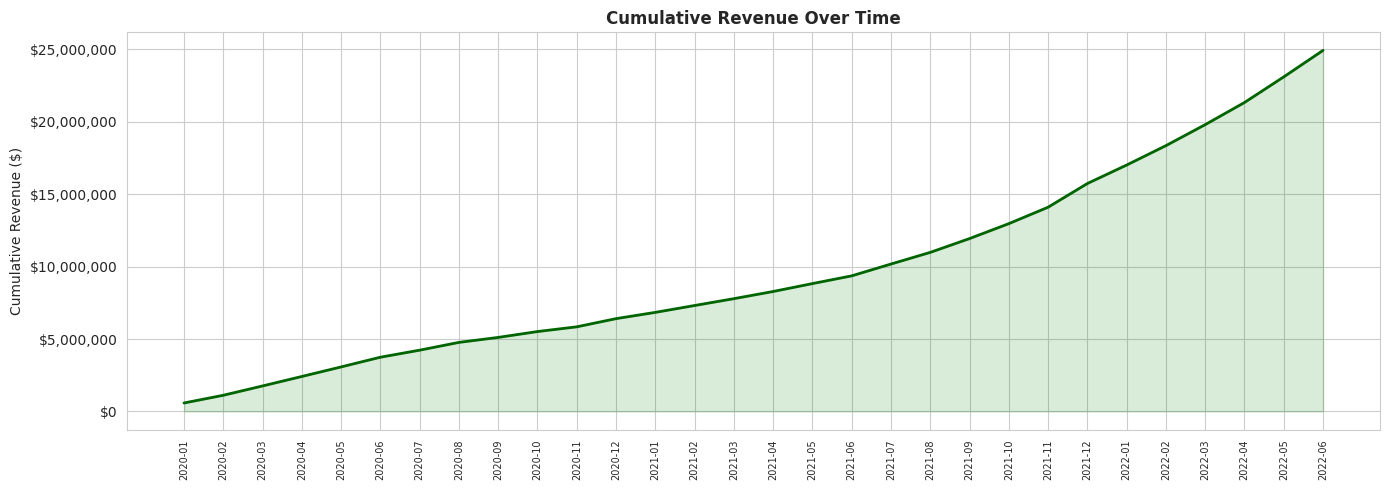

In [6]:
monthly['CumulativeRevenue'] = monthly['Revenue'].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['OrderYearMonth'], monthly['CumulativeRevenue'], color='darkgreen', linewidth=2)
ax.fill_between(monthly['OrderYearMonth'], monthly['CumulativeRevenue'], alpha=0.15, color='green')
ax.set_title('Cumulative Revenue Over Time')
ax.set_ylabel('Cumulative Revenue ($)')
money_fmt(ax)
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()


### 2.5 Seasonality — Average Revenue by Calendar Month

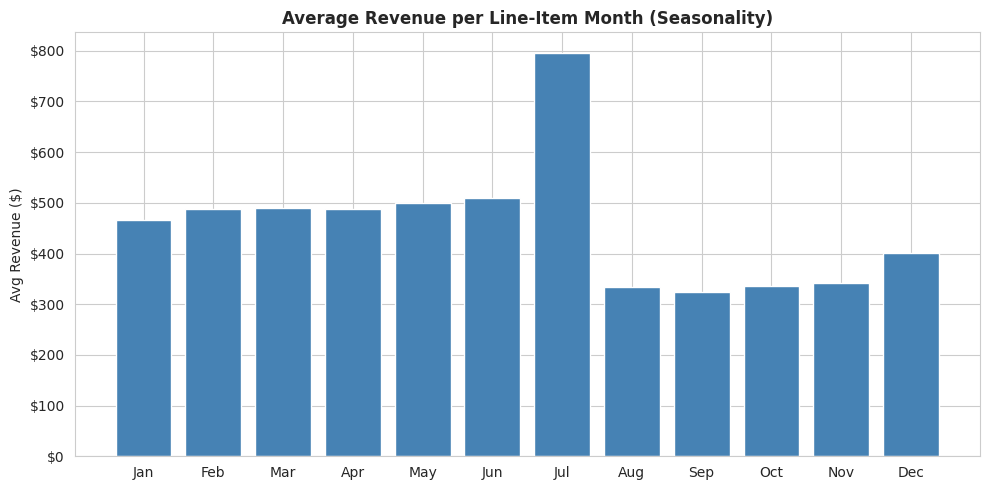

In [7]:
seasonality = master_df.groupby('OrderMonth')['Revenue'].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(seasonality['OrderMonth'], seasonality['Revenue'], color='steelblue')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Average Revenue per Line-Item Month (Seasonality)')
ax.set_ylabel('Avg Revenue ($)')
money_fmt(ax)
plt.tight_layout()
plt.show()


### 2.6 Weekday vs. Weekend Orders

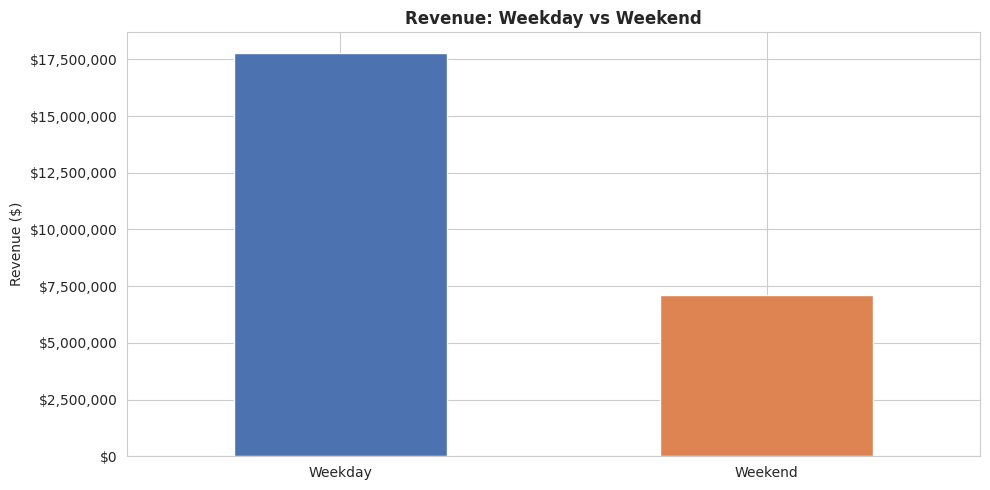

In [8]:
weekend_rev = master_df.groupby('IsWeekend')['Revenue'].sum()
weekend_rev.index = ['Weekday', 'Weekend']

ax = weekend_rev.plot(kind='bar', color=['#4C72B0', '#DD8452'])
ax.set_title('Revenue: Weekday vs Weekend')
ax.set_ylabel('Revenue ($)')
money_fmt(ax)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 3. Product & Category Analysis

### 3.1 Revenue by Category

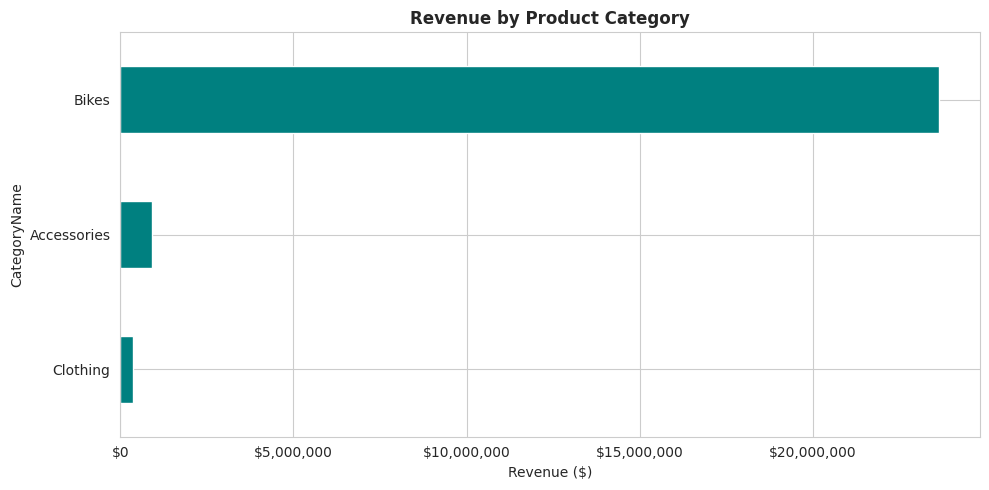

In [9]:
cat_rev = master_df.groupby('CategoryName')['Revenue'].sum().sort_values(ascending=False)

ax = cat_rev.plot(kind='barh', color='teal')
ax.set_title('Revenue by Product Category')
ax.set_xlabel('Revenue ($)')
money_fmt(ax, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 3.2 Revenue by Subcategory (Top 15)

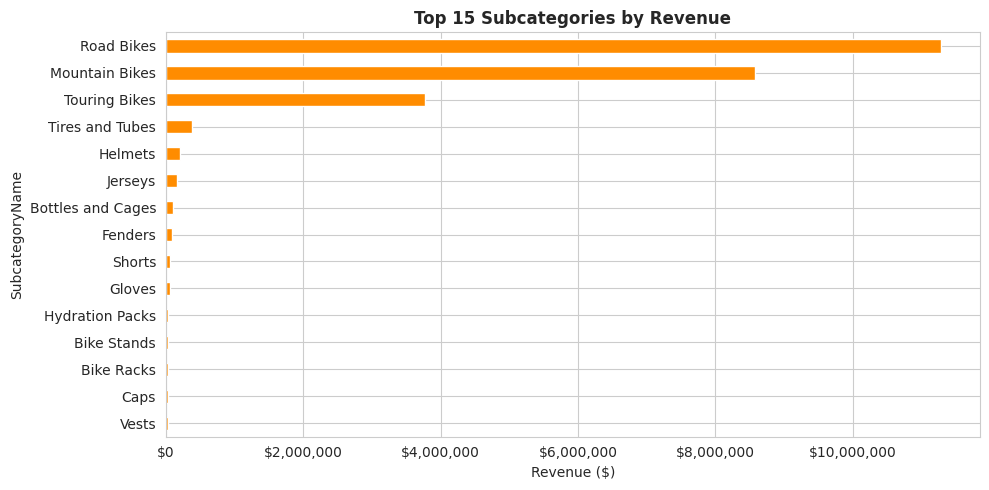

In [10]:
subcat_rev = master_df.groupby('SubcategoryName')['Revenue'].sum().sort_values(ascending=False).head(15)

ax = subcat_rev.plot(kind='barh', color='darkorange')
ax.set_title('Top 15 Subcategories by Revenue')
ax.set_xlabel('Revenue ($)')
money_fmt(ax, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 3.3 Top 10 Products by Revenue

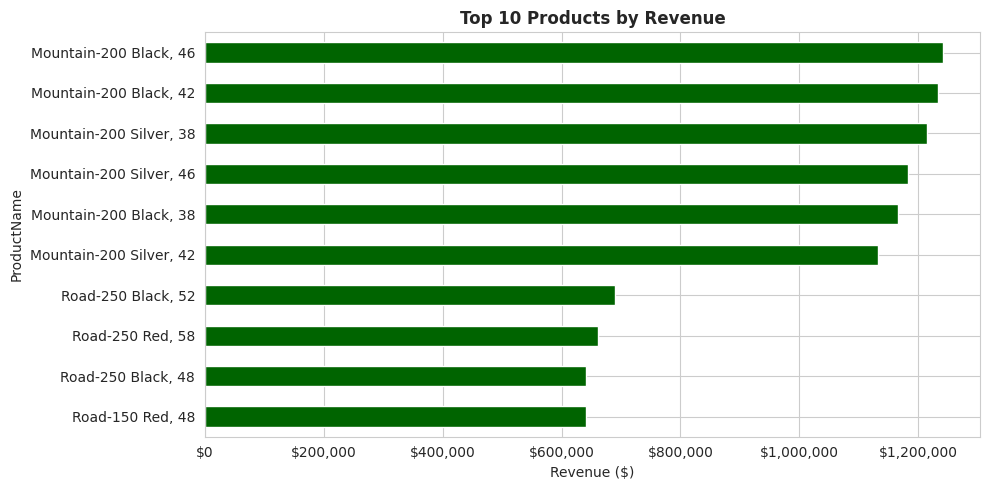

In [11]:
top_products = master_df.groupby('ProductName')['Revenue'].sum().sort_values(ascending=False).head(10)

ax = top_products.plot(kind='barh', color='darkgreen')
ax.set_title('Top 10 Products by Revenue')
ax.set_xlabel('Revenue ($)')
money_fmt(ax, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 3.4 Bottom 10 Products by Revenue

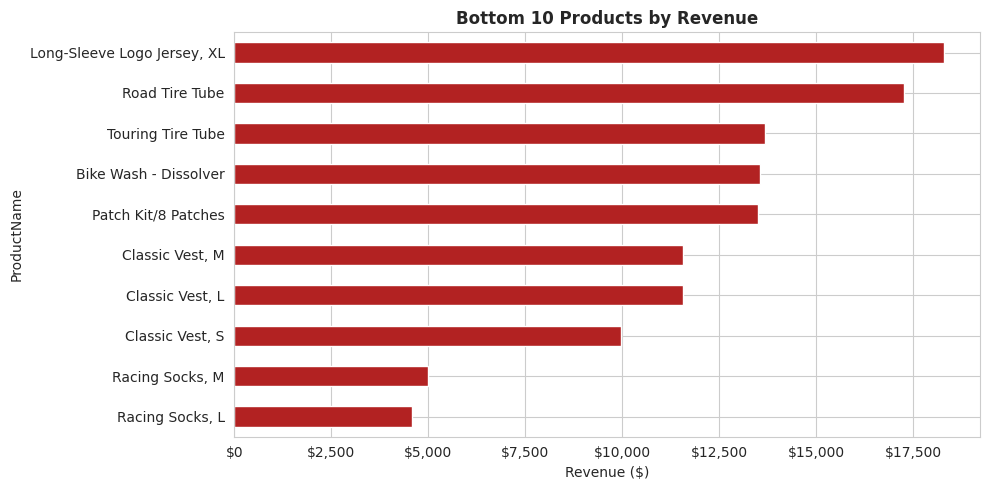

In [12]:
bottom_products = master_df.groupby('ProductName')['Revenue'].sum().sort_values(ascending=True).head(10)

ax = bottom_products.plot(kind='barh', color='firebrick')
ax.set_title('Bottom 10 Products by Revenue')
ax.set_xlabel('Revenue ($)')
money_fmt(ax, axis='x')
plt.tight_layout()
plt.show()


### 3.5 Pareto Analysis (80/20 Rule)

Do ~20% of products drive ~80% of revenue?

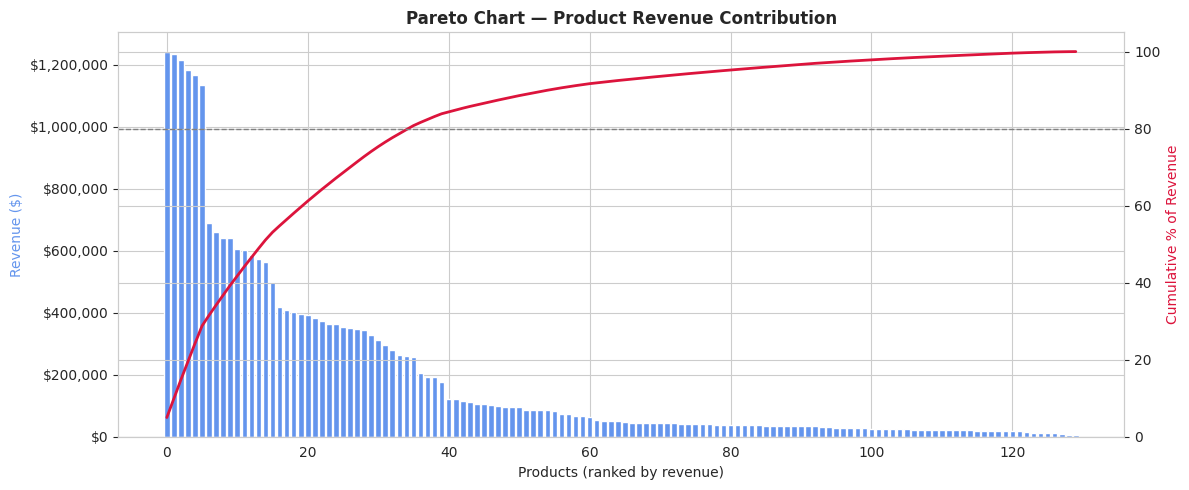

26.9% of products generate 80% of total revenue.


In [13]:
product_rev = master_df.groupby('ProductName')['Revenue'].sum().sort_values(ascending=False).reset_index()
product_rev['CumulativeRevenue'] = product_rev['Revenue'].cumsum()
product_rev['CumulativePct'] = product_rev['CumulativeRevenue'] / product_rev['Revenue'].sum() * 100
product_rev['ProductRankPct'] = (np.arange(1, len(product_rev) + 1) / len(product_rev)) * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(range(len(product_rev)), product_rev['Revenue'], color='cornflowerblue')
ax1.set_ylabel('Revenue ($)', color='cornflowerblue')
money_fmt(ax1)

ax2 = ax1.twinx()
ax2.plot(range(len(product_rev)), product_rev['CumulativePct'], color='crimson', linewidth=2)
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative % of Revenue', color='crimson')
ax2.set_ylim(0, 105)

ax1.set_title('Pareto Chart — Product Revenue Contribution')
ax1.set_xlabel('Products (ranked by revenue)')
plt.tight_layout()
plt.show()

pct_products_for_80 = (product_rev['CumulativePct'] <= 80).sum() / len(product_rev) * 100
print(f'{pct_products_for_80:.1f}% of products generate 80% of total revenue.')


### 3.6 ABC Classification

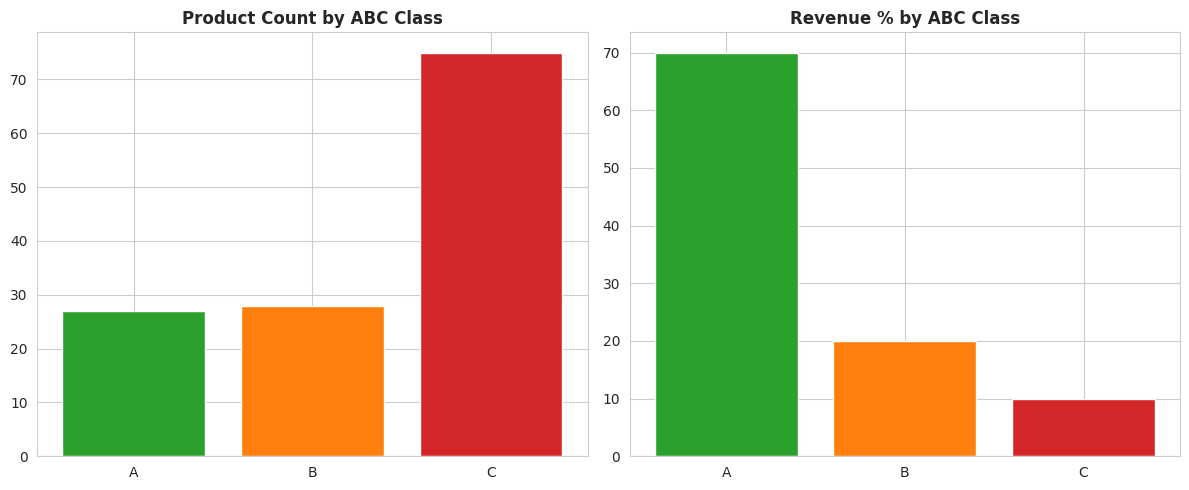

,ProductCount,TotalRevenue,RevenuePct
ABC_Class,,,
A,27,1.743214e+07,70.0
B,28,4.981760e+06,20.0
C,75,2.500685e+06,10.0


In [14]:
product_rev['ABC_Class'] = np.where(
    product_rev['CumulativePct'] <= 70, 'A',
    np.where(product_rev['CumulativePct'] <= 90, 'B', 'C')
)

abc_summary = product_rev.groupby('ABC_Class').agg(
    ProductCount=('ProductName', 'count'),
    TotalRevenue=('Revenue', 'sum')
)
abc_summary['RevenuePct'] = (abc_summary['TotalRevenue'] / abc_summary['TotalRevenue'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(abc_summary.index, abc_summary['ProductCount'], color=['#2ca02c', '#ff7f0e', '#d62728'])
axes[0].set_title('Product Count by ABC Class')
axes[1].bar(abc_summary.index, abc_summary['RevenuePct'], color=['#2ca02c', '#ff7f0e', '#d62728'])
axes[1].set_title('Revenue % by ABC Class')
plt.tight_layout()
plt.show()

abc_summary


### 3.7 Product Margin Distribution

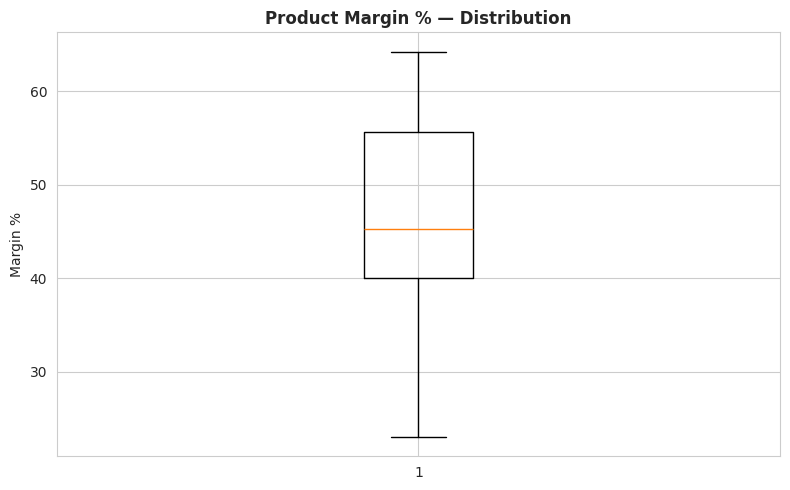

count    293.000000
mean      47.641195
std        9.226550
min       23.000000
25%       40.060000
50%       45.240000
75%       55.600000
max       64.250000
Name: ProductMarginPct, dtype: float64


In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(product_df['ProductMarginPct'].dropna())
ax.set_title('Product Margin % — Distribution')
ax.set_ylabel('Margin %')
plt.tight_layout()
plt.show()

print(product_df['ProductMarginPct'].describe())


## 4. Customer Analysis

### 4.1 Top 10 Customers by Revenue

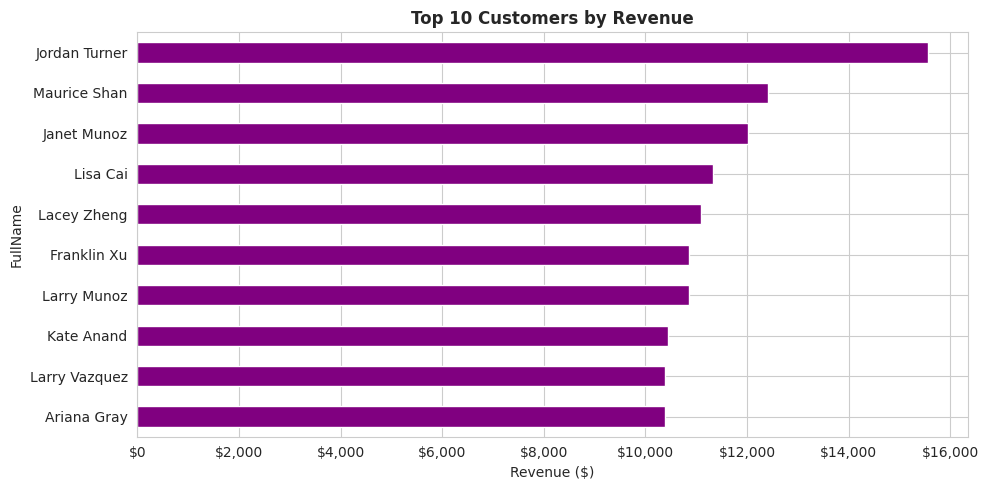

In [16]:
top_customers = master_df.groupby('FullName')['Revenue'].sum().sort_values(ascending=False).head(10)

ax = top_customers.plot(kind='barh', color='purple')
ax.set_title('Top 10 Customers by Revenue')
ax.set_xlabel('Revenue ($)')
money_fmt(ax, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 4.2 Revenue by Gender

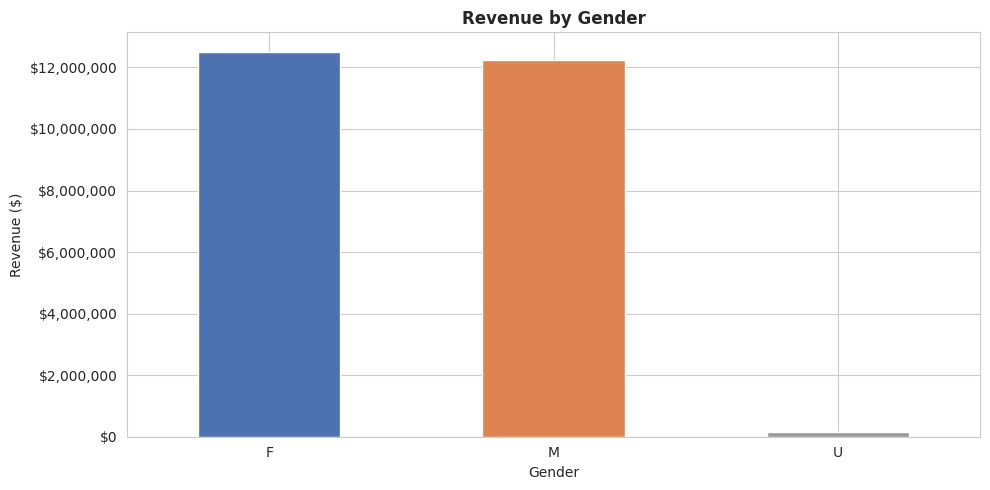

In [17]:
gender_rev = master_df.groupby('Gender')['Revenue'].sum()

ax = gender_rev.plot(kind='bar', color=['#4C72B0', '#DD8452', '#999999'])
ax.set_title('Revenue by Gender')
ax.set_ylabel('Revenue ($)')
money_fmt(ax)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 4.3 Income Analysis

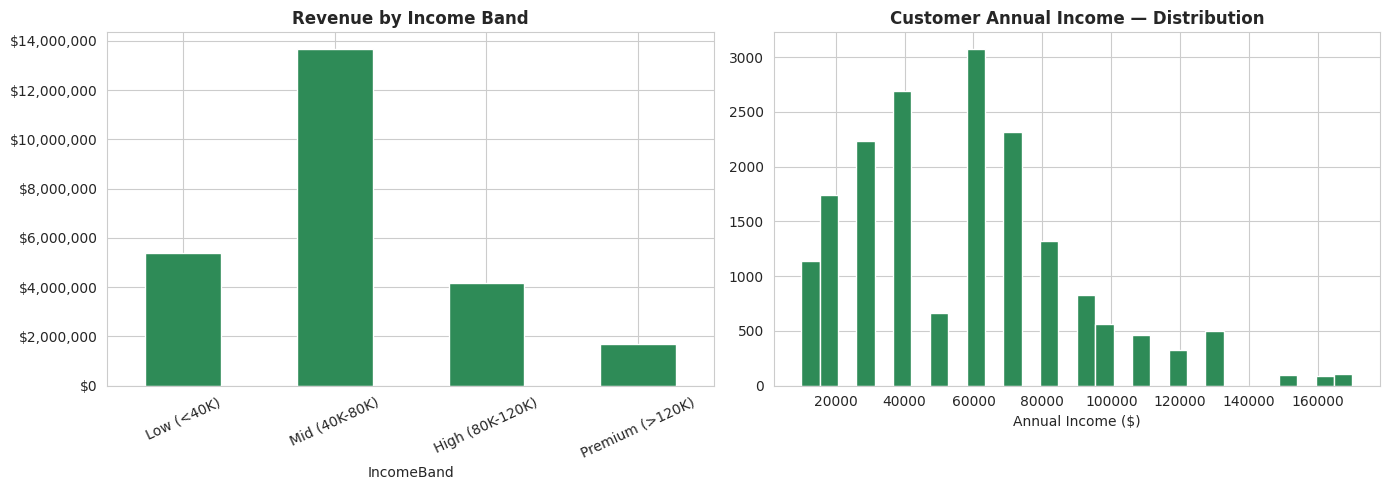

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

income_rev = master_df.groupby('IncomeBand')['Revenue'].sum()
order = ['Low (<40K)', 'Mid (40K-80K)', 'High (80K-120K)', 'Premium (>120K)']
income_rev = income_rev.reindex(order)
income_rev.plot(kind='bar', ax=axes[0], color='seagreen')
axes[0].set_title('Revenue by Income Band')
money_fmt(axes[0])
axes[0].tick_params(axis='x', rotation=25)

axes[1].hist(customer_df['AnnualIncome_USD'], bins=30, color='seagreen', edgecolor='white')
axes[1].set_title('Customer Annual Income — Distribution')
axes[1].set_xlabel('Annual Income ($)')

plt.tight_layout()
plt.show()


### 4.4 Age Analysis

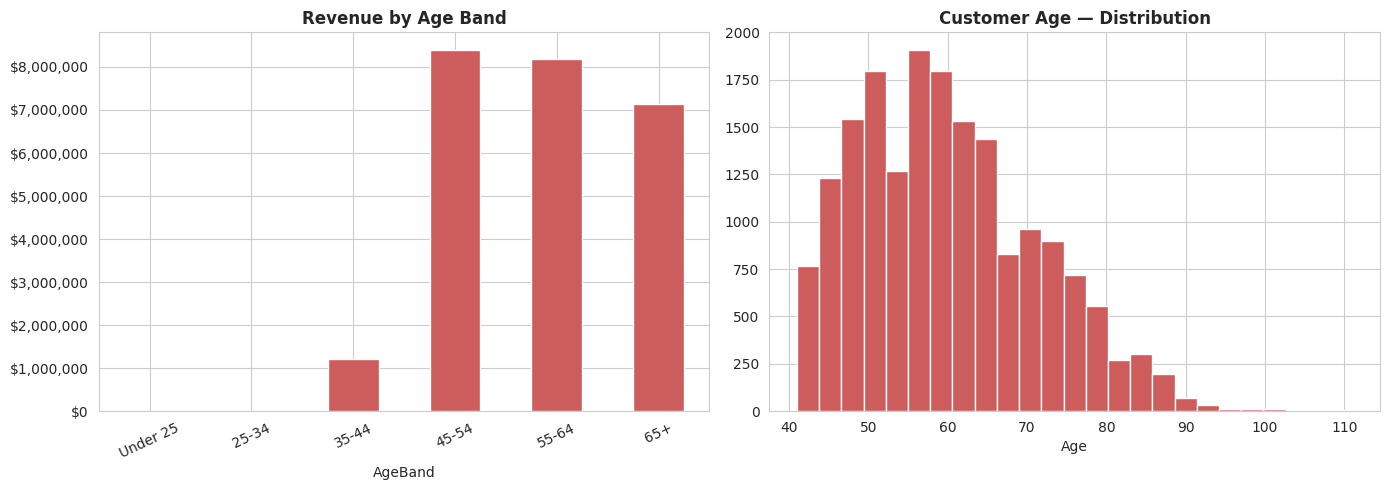

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_rev = master_df.groupby('AgeBand')['Revenue'].sum()
age_order = ['Under 25', '25-34', '35-44', '45-54', '55-64', '65+']
age_rev = age_rev.reindex(age_order)
age_rev.plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set_title('Revenue by Age Band')
money_fmt(axes[0])
axes[0].tick_params(axis='x', rotation=25)

axes[1].hist(customer_df['Age'], bins=25, color='indianred', edgecolor='white')
axes[1].set_title('Customer Age — Distribution')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()


### 4.5 Revenue by Occupation

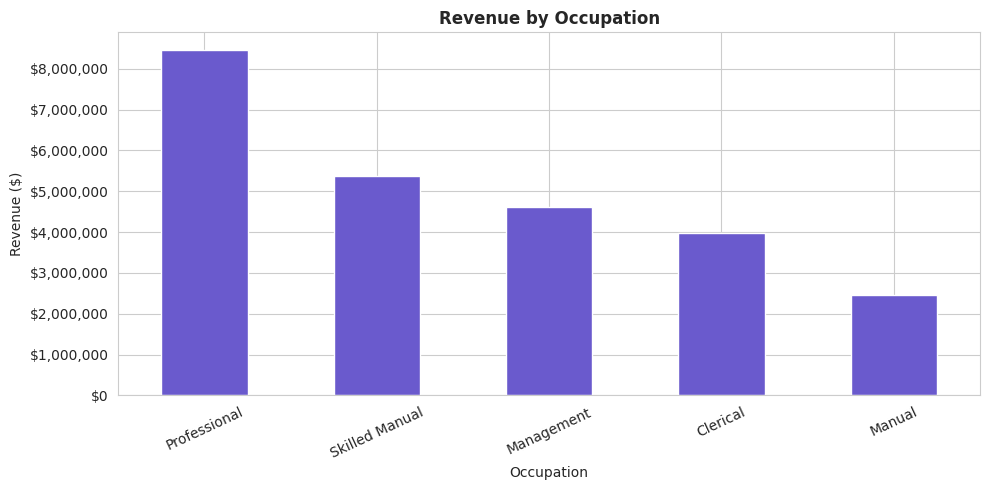

In [20]:
occ_rev = master_df.groupby('Occupation')['Revenue'].sum().sort_values(ascending=False)

ax = occ_rev.plot(kind='bar', color='slateblue')
ax.set_title('Revenue by Occupation')
ax.set_ylabel('Revenue ($)')
money_fmt(ax)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


## 5. Geographic Analysis

### 5.1 Revenue by Country

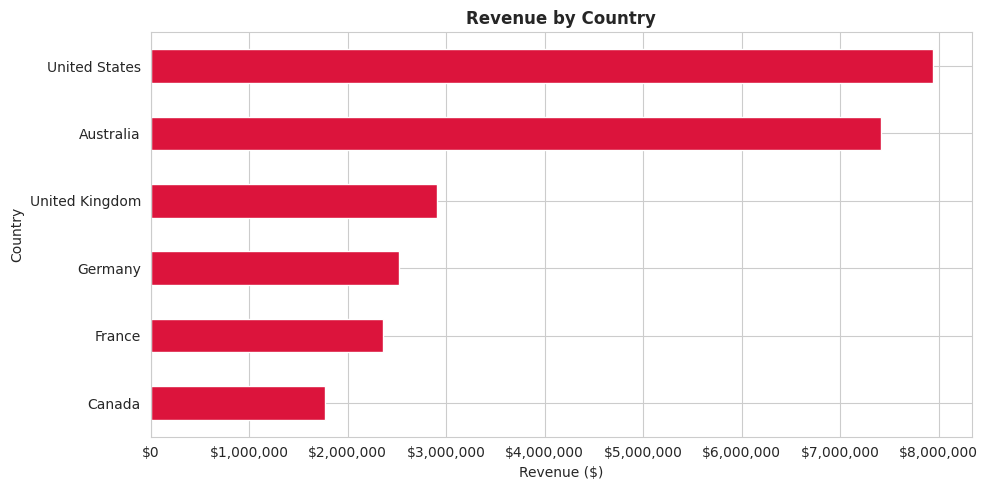

In [21]:
country_rev = master_df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

ax = country_rev.plot(kind='barh', color='crimson')
ax.set_title('Revenue by Country')
ax.set_xlabel('Revenue ($)')
money_fmt(ax, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 5.2 Revenue by Region (Top 10)

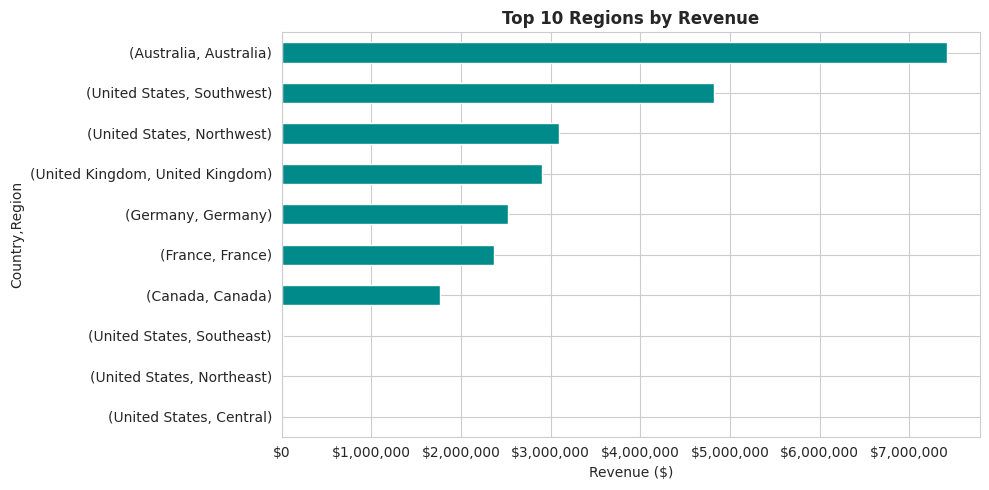

In [22]:
region_rev = master_df.groupby(['Country', 'Region'])['Revenue'].sum().sort_values(ascending=False).head(10)

ax = region_rev.plot(kind='barh', color='darkcyan')
ax.set_title('Top 10 Regions by Revenue')
ax.set_xlabel('Revenue ($)')
money_fmt(ax, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 6. Returns Analysis

### 6.1 Overall Return Rate

In [23]:
total_units_sold = master_df['Quantity'].sum()
total_units_returned = returns_df['ReturnQuantity'].sum()
return_rate = total_units_returned / total_units_sold * 100

print(f'Total units sold: {total_units_sold:,}')
print(f'Total units returned: {total_units_returned:,}')
print(f'Overall return rate: {return_rate:.2f}%')


Total units sold: 84,174
Total units returned: 1,828
Overall return rate: 2.17%


### 6.2 Return Rate by Category

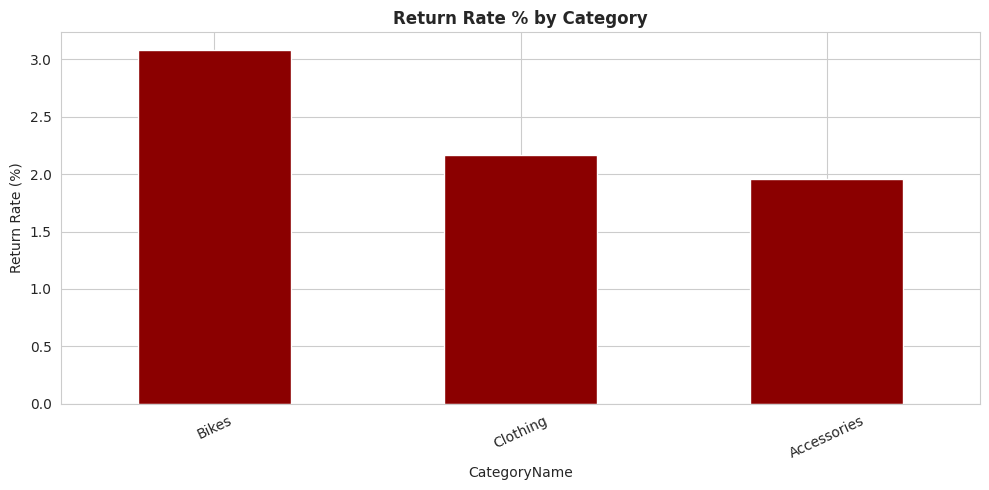

In [24]:
returns_with_products = returns_df.merge(
    product_df[['ProductKey', 'CategoryName']], on='ProductKey', how='left'
)
returns_by_cat = returns_with_products.groupby('CategoryName')['ReturnQuantity'].sum()
sold_by_cat = master_df.groupby('CategoryName')['Quantity'].sum()

return_rate_cat = (returns_by_cat / sold_by_cat * 100).sort_values(ascending=False)

ax = return_rate_cat.plot(kind='bar', color='darkred')
ax.set_title('Return Rate % by Category')
ax.set_ylabel('Return Rate (%)')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


### 6.3 Top 10 Most-Returned Products

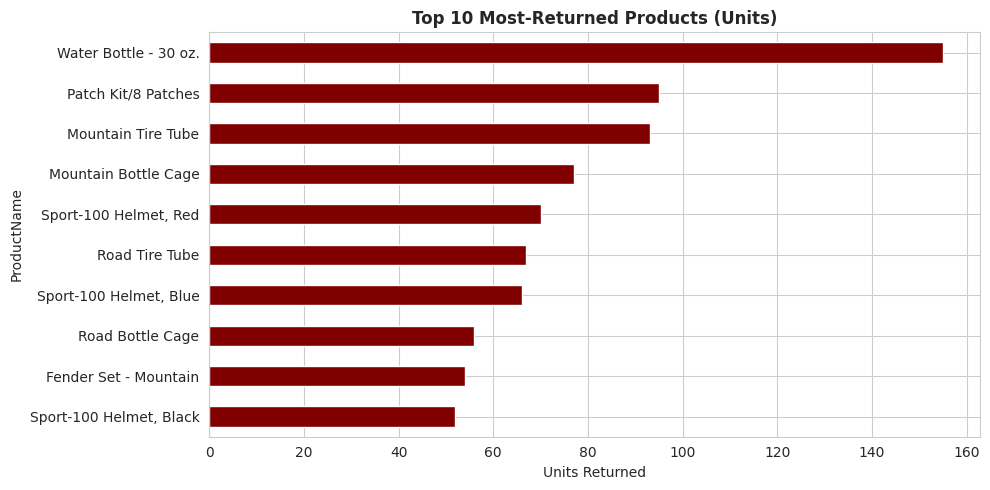

In [25]:
top_returned = returns_with_products.merge(
    product_df[['ProductKey', 'ProductName']], on='ProductKey', how='left'
).groupby('ProductName')['ReturnQuantity'].sum().sort_values(ascending=False).head(10)

ax = top_returned.plot(kind='barh', color='maroon')
ax.set_title('Top 10 Most-Returned Products (Units)')
ax.set_xlabel('Units Returned')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 6.4 Monthly Returns Trend

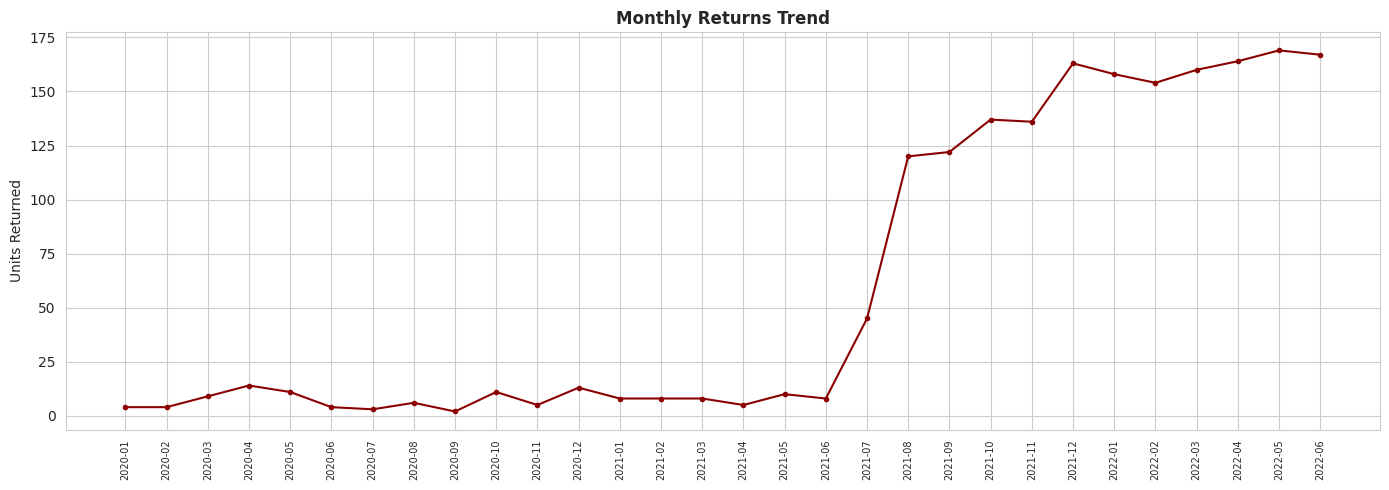

In [26]:
returns_df['ReturnYearMonth'] = returns_df['ReturnDate'].dt.to_period('M').astype(str)
monthly_returns = returns_df.groupby('ReturnYearMonth')['ReturnQuantity'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_returns['ReturnYearMonth'], monthly_returns['ReturnQuantity'], marker='o', markersize=3, color='darkred')
ax.set_title('Monthly Returns Trend')
ax.set_ylabel('Units Returned')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()


## 7. Correlation & Distribution Analysis

### 7.1 Correlation Heatmap

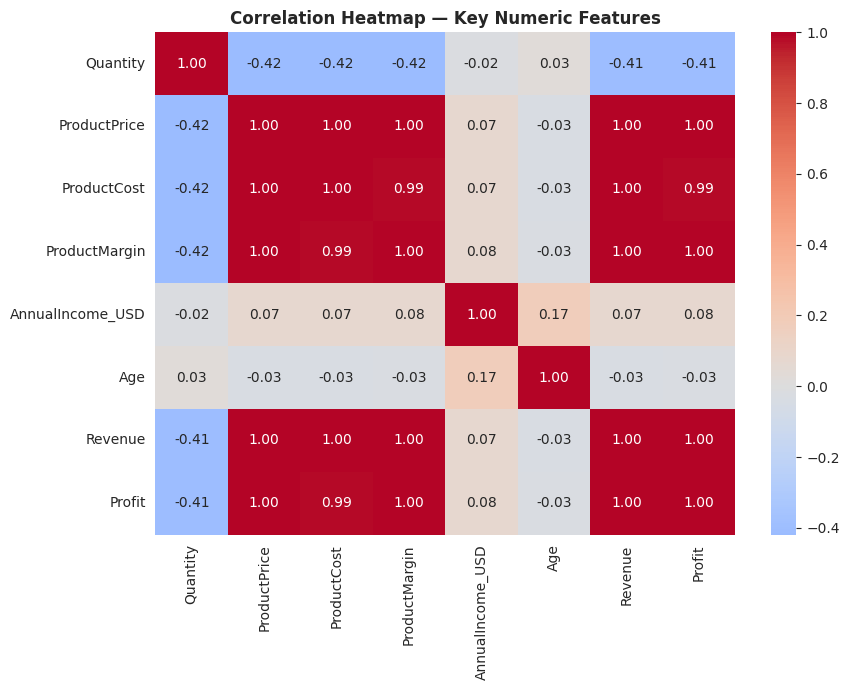

In [27]:
corr_cols = ['Quantity', 'ProductPrice', 'ProductCost', 'ProductMargin',
             'AnnualIncome_USD', 'Age', 'Revenue', 'Profit']
corr = master_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap — Key Numeric Features')
plt.tight_layout()
plt.show()


### 7.2 Scatterplot — Product Price vs. Quantity Sold

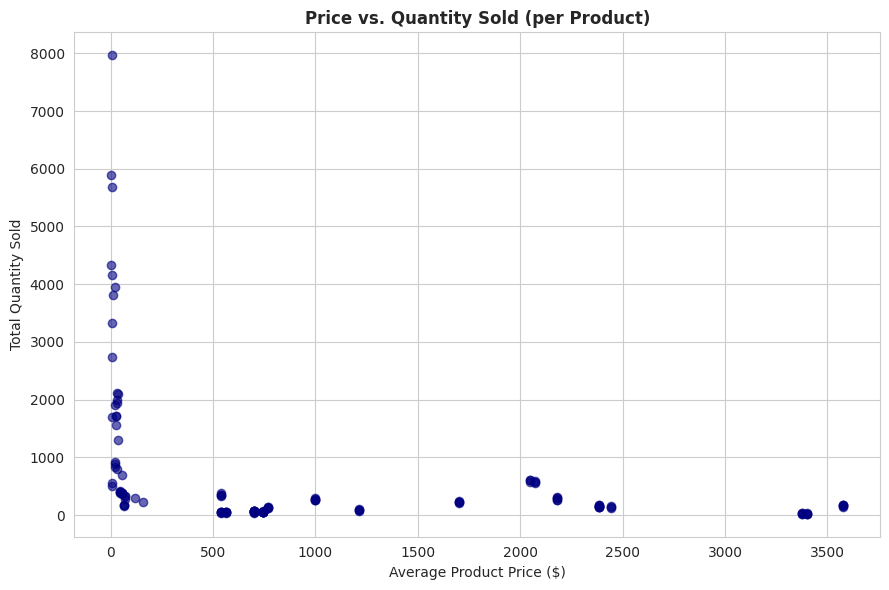

In [28]:
price_qty = master_df.groupby('ProductName').agg(
    AvgPrice=('ProductPrice', 'mean'),
    TotalQuantity=('Quantity', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(price_qty['AvgPrice'], price_qty['TotalQuantity'], alpha=0.6, color='navy')
ax.set_xlabel('Average Product Price ($)')
ax.set_ylabel('Total Quantity Sold')
ax.set_title('Price vs. Quantity Sold (per Product)')
plt.tight_layout()
plt.show()


### 7.3 Scatterplot — Customer Income vs. Revenue Per Customer

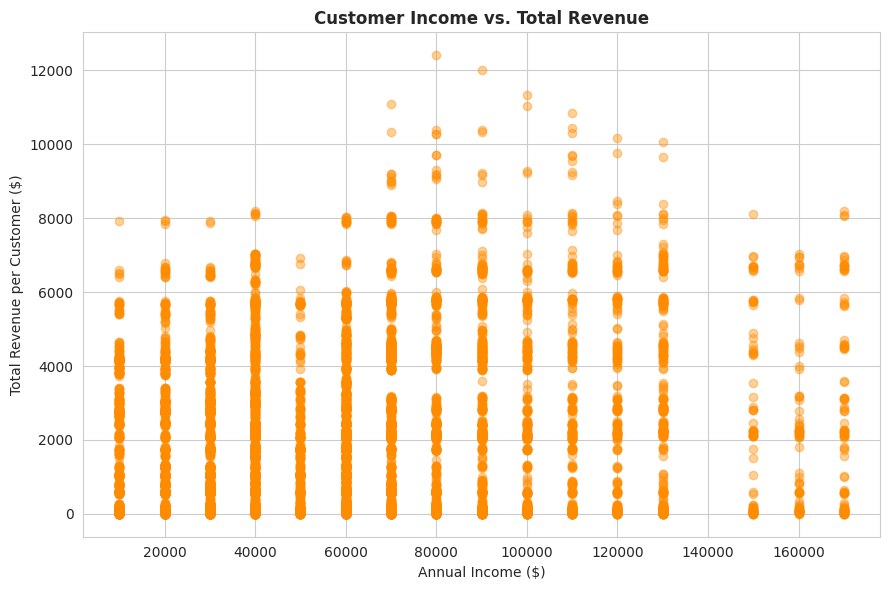

Correlation (Income vs Revenue): 0.162


In [29]:
cust_rev = master_df.groupby('CustomerKey').agg(TotalRevenue=('Revenue', 'sum')).reset_index()
cust_rev = cust_rev.merge(customer_df[['CustomerKey', 'AnnualIncome_USD']], on='CustomerKey', how='left')

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(cust_rev['AnnualIncome_USD'], cust_rev['TotalRevenue'], alpha=0.4, color='darkorange')
ax.set_xlabel('Annual Income ($)')
ax.set_ylabel('Total Revenue per Customer ($)')
ax.set_title('Customer Income vs. Total Revenue')
plt.tight_layout()
plt.show()

print('Correlation (Income vs Revenue):', cust_rev['AnnualIncome_USD'].corr(cust_rev['TotalRevenue']).round(3))


### 7.4 Boxplot — Revenue Distribution by Category

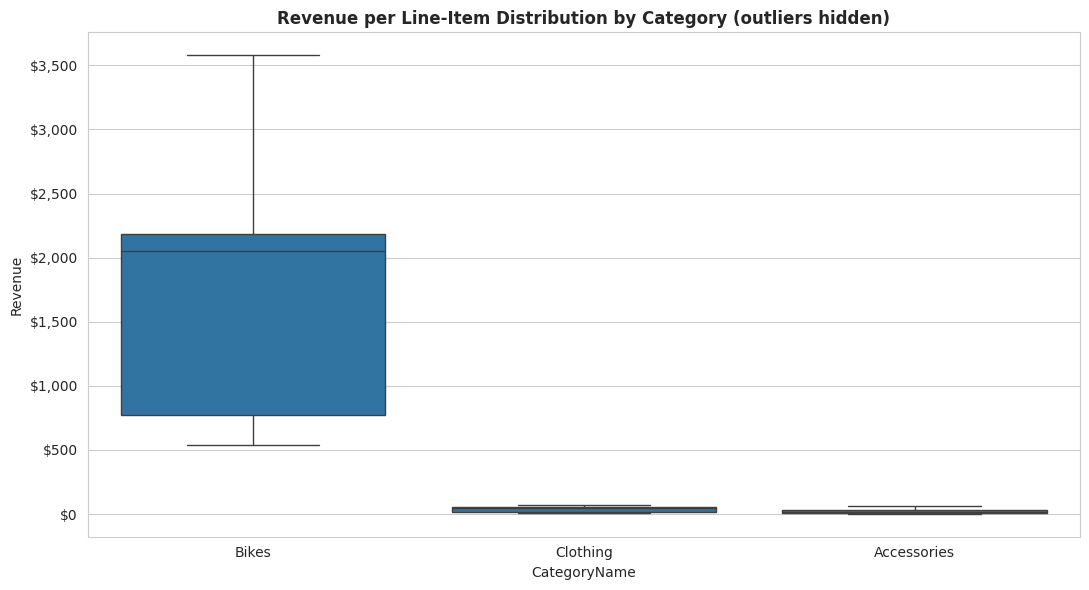

In [30]:
fig, ax = plt.subplots(figsize=(11, 6))
order = master_df.groupby('CategoryName')['Revenue'].median().sort_values(ascending=False).index
sns.boxplot(data=master_df, x='CategoryName', y='Revenue', order=order, ax=ax, showfliers=False)
ax.set_title('Revenue per Line-Item Distribution by Category (outliers hidden)')
money_fmt(ax)
plt.tight_layout()
plt.show()


### 7.5 Boxplot — Customer Age by Income Band

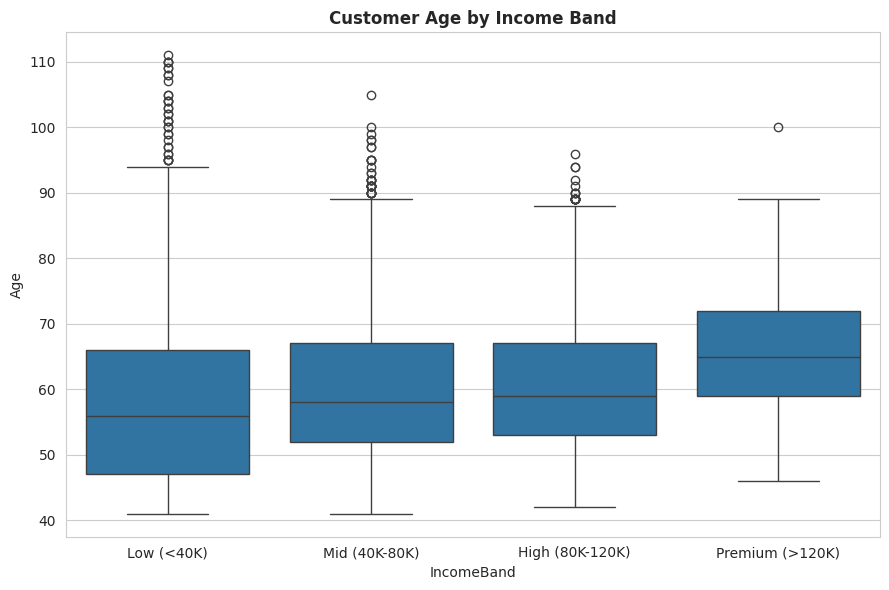

In [31]:
fig, ax = plt.subplots(figsize=(9, 6))
order = ['Low (<40K)', 'Mid (40K-80K)', 'High (80K-120K)', 'Premium (>120K)']
sns.boxplot(data=customer_df, x='IncomeBand', y='Age', order=order, ax=ax)
ax.set_title('Customer Age by Income Band')
plt.tight_layout()
plt.show()


## 8. Key Insights Summary

In [32]:
total_revenue = master_df['Revenue'].sum()
total_profit = master_df['Profit'].sum()
top_category = cat_rev.idxmax()
top_country = country_rev.idxmax()
top_product = top_products.idxmax()

print('KEY INSIGHTS')
print('=' * 50)
print(f'- Total Revenue: ${total_revenue:,.0f}  |  Total Profit: ${total_profit:,.0f}')
print(f'- Overall Profit Margin: {total_profit/total_revenue*100:.1f}%')
print(f'- Top Category: {top_category} (${cat_rev.max():,.0f})')
print(f'- Top Country: {top_country} (${country_rev.max():,.0f})')
print(f'- Top Product: {top_product} (${top_products.max():,.0f})')
print(f'- Overall Return Rate: {return_rate:.2f}%')
print(f'- {pct_products_for_80:.1f}% of products drive 80% of revenue (Pareto effect confirmed)')


KEY INSIGHTS
- Total Revenue: $24,914,587  |  Total Profit: $10,457,715
- Overall Profit Margin: 42.0%
- Top Category: Bikes ($23,642,495)
- Top Country: United States ($7,938,999)
- Top Product: Mountain-200 Black, 46 ($1,241,754)
- Overall Return Rate: 2.17%
- 26.9% of products drive 80% of revenue (Pareto effect confirmed)


---
**Next step:** These findings feed directly into the Power BI report
(`Power BI/Apex Moto Report.pbix`) and the project `README.md`, which
translates them into a portfolio narrative with quantified highlights.